# Homework: Automated Preprocessing Pipeline with Titanic

---

## 1. Initial exploration of the dataset

In [1]:
import pandas as pd

titanic_df = pd.read_csv("data/Titanic-Dataset.csv")

titanic_df_raw = titanic_df.copy()

Let's take a first look on the five initial records on the dataset

In [2]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The first step that I want to do is analyze the following information:
- Number total of records
- Number of columns and the data type of each one
- Number of null and duplicated values

In [3]:
print(f"Total Number of records on the dataset {titanic_df.shape[0]}\n")
print(f"Number of columns: {len(list(titanic_df.columns))}\n")
print("Data types of the columns\n")
titanic_df.info()

Total Number of records on the dataset 891

Number of columns: 12

Data types of the columns

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


With the above output we can see the following number of data types:
- five ``int64`` data types
- five `str` data types
- two `float64` data types

---

In [4]:
# Analyze the total number of Null Values in each column of the dataset

titanic_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
# Analyze the total of duplicates on the dataset

titanic_df.duplicated().sum()

np.int64(0)

Above information show us that the following columns: `Age`, `Cabin`, `Embarked`. Have null values, and the most important specific case is the `Age` and `Embarked` columns, which are a lot of `Null` values, respecto to the total number of records. In the other hand, respecto to **duplicate values**, we have evidence by the code (`DataFraduplicated().sum()`), that we don't have any duplicated record on our dataset.

---

### 1.1 Deep exploration about the variables on Titanic Dataset

In [6]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
# First we need to divide into two lists the name of categorical and numerical variables of the dataset

var_categorical = ["Name", "Sex", "Ticket", "Cabin", "Embarked"]
var_numerical = ["PassengerId", "Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]

We know that the objective of this problem is using a Machine Learning but why?

The idea behind Machine Learning models, specifically for ``LogisticRegressionModel`` which are the implemented model in this work. Is generalize
the relation between an input (vector of features named $\textbf{X}$) with their Output $\textbf{Y}$ with a function or model named $\textbf{h(X)}$. The idea is that the error between the estimated (or predicted) value given by $h(X)$ must be near to zero comparing with the real value.

So, with that idea. Which feature makes sense to use as the final prediction target? For responding that question, we can do a brief exploration about the unique values for each feature.

In [8]:
titanic_df["PassengerId"].unique()[:10]

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [9]:
titanic_df.columns[:4]

Index(['PassengerId', 'Survived', 'Pclass', 'Name'], dtype='str')

In [10]:
for feature in titanic_df.columns[:4]:
    print(f"Unique Values for {feature.upper()} column")
    print(list(titanic_df[feature].unique())[:10], end=" ")
    if len(titanic_df[feature].unique()) > 10:
        print(".... MORE VALUES", end=" ")
    print()
    print()

Unique Values for PASSENGERID column
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)] .... MORE VALUES 

Unique Values for SURVIVED column
[np.int64(0), np.int64(1)] 

Unique Values for PCLASS column
[np.int64(3), np.int64(1), np.int64(2)] 

Unique Values for NAME column
['Braund, Mr. Owen Harris', 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)', 'Heikkinen, Miss. Laina', 'Futrelle, Mrs. Jacques Heath (Lily May Peel)', 'Allen, Mr. William Henry', 'Moran, Mr. James', 'McCarthy, Mr. Timothy J', 'Palsson, Master. Gosta Leonard', 'Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)', 'Nasser, Mrs. Nicholas (Adele Achem)'] .... MORE VALUES 



In [11]:
for feature in titanic_df.columns[4:7]:
    print(f"Unique Values for {feature.upper()} column")
    print(list(titanic_df[feature].unique())[:10], end=" ")
    if len(titanic_df[feature].unique()) > 10:
        print(".... MORE VALUES", end=" ")
    print()
    print()

Unique Values for SEX column
['male', 'female'] 

Unique Values for AGE column
[np.float64(22.0), np.float64(38.0), np.float64(26.0), np.float64(35.0), np.float64(nan), np.float64(54.0), np.float64(2.0), np.float64(27.0), np.float64(14.0), np.float64(4.0)] .... MORE VALUES 

Unique Values for SIBSP column
[np.int64(1), np.int64(0), np.int64(3), np.int64(4), np.int64(2), np.int64(5), np.int64(8)] 



In [12]:
for feature in titanic_df.columns[7:]:
    print(f"Unique Values for {feature.upper()} column")
    print(list(titanic_df[feature].unique())[:10], end=" ")
    if len(titanic_df[feature].unique()) > 10:
        print(".... MORE VALUES", end=" ")
    print()
    print()

Unique Values for PARCH column
[np.int64(0), np.int64(1), np.int64(2), np.int64(5), np.int64(3), np.int64(4), np.int64(6)] 

Unique Values for TICKET column
['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450', '330877', '17463', '349909', '347742', '237736'] .... MORE VALUES 

Unique Values for FARE column
[np.float64(7.25), np.float64(71.2833), np.float64(7.925), np.float64(53.1), np.float64(8.05), np.float64(8.4583), np.float64(51.8625), np.float64(21.075), np.float64(11.1333), np.float64(30.0708)] .... MORE VALUES 

Unique Values for CABIN column
[nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6', 'C23 C25 C27', 'B78'] .... MORE VALUES 

Unique Values for EMBARKED column
['S', 'C', 'Q', nan] 



Checking the unique values on the above code the best candidates depends on the problem that we want to solve and discover. For example if we want to *predict* the age of a person depending on their social class, destination, sex, etc, we can use Machine Learning models as a regression  problem, but it doesn't much sense find a function to map and predict the age of a person depends on other features. 

In the other hand, other type of approach to solve problems with Machine Learning models, are classification, for example wen can consider the features of a person to predict if its man or female, but also we have the possibilty to take a more interesting way. For example, given the features of a person we can *predict* whether or not it survive. 

*For this work* I'm going taking that way. I'd like extract the features on the dataset for each person (except of `Survived` column), to predict whether or not it **survive**. To achieve this objective, I have to use the `Logistic Regression` function and find the optimal values of $\theta$'s for having a function $\textbf{h(x)}$ which map the relation and solve my problem of binary classification.

---

Finally, before to implement the Machine Learning model, is a bad practical put all features into the model, because could be have feature which have more importance than others. Although a lot of values does not cause a bad performance on the model, they can increase the training time, because the dimensions which the model need to manage could be strong to process. In this notebook with a brief EDA, I'm going to reccomend you what variables could be drop from the dataset for reduce the dimension of the features used by the model.

#### **1.1 Histogram plot (Frequency Ages per class)**

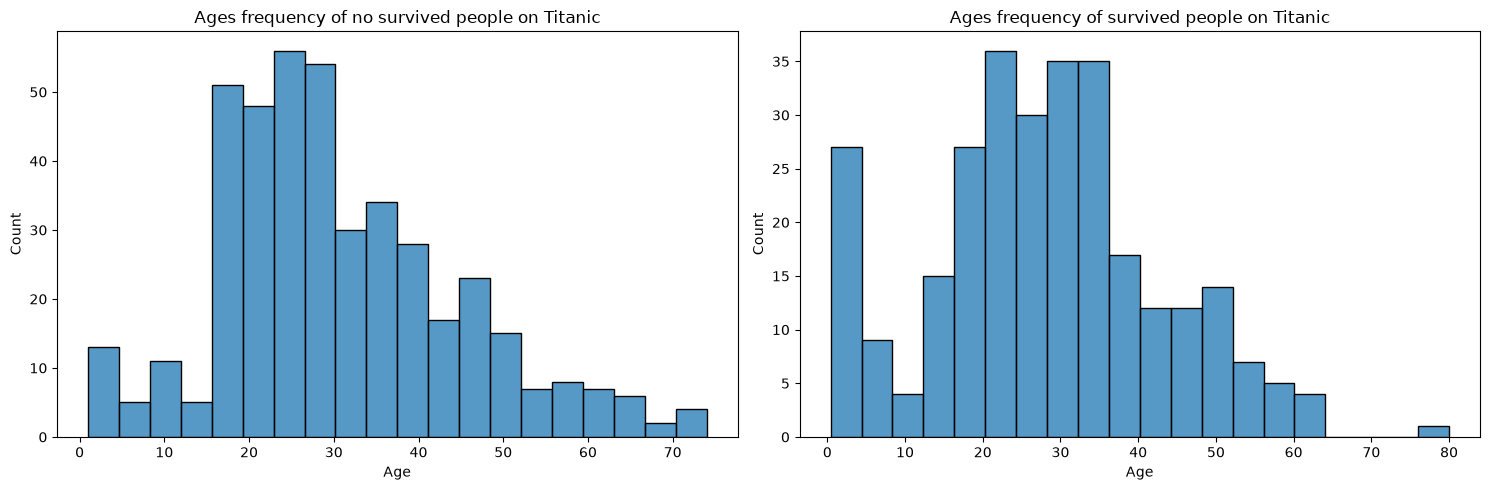

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(titanic_df[titanic_df["Survived"] == 0]["Age"], edgecolor="black", bins=20, ax=axes[0])
axes[0].set_title("Ages frequency of no survived people on Titanic")

sns.histplot(titanic_df[titanic_df["Survived"] == 1]["Age"], edgecolor="black", bins=20, ax=axes[1])
axes[1].set_title("Ages frequency of survived people on Titanic")

plt.tight_layout()
plt.show()

In the plot above, we can see that the age distribution varies depending on whether or not the person survived. In the case of the group that survived, the ages are lower, but starting at age 50, the frequency is lower than among those who did not survive. This histogram suggest that the `Age` variable is significant and influences the final outcome of wheter a person survived or not.

---

#### **1.2 Bar plots per sex**

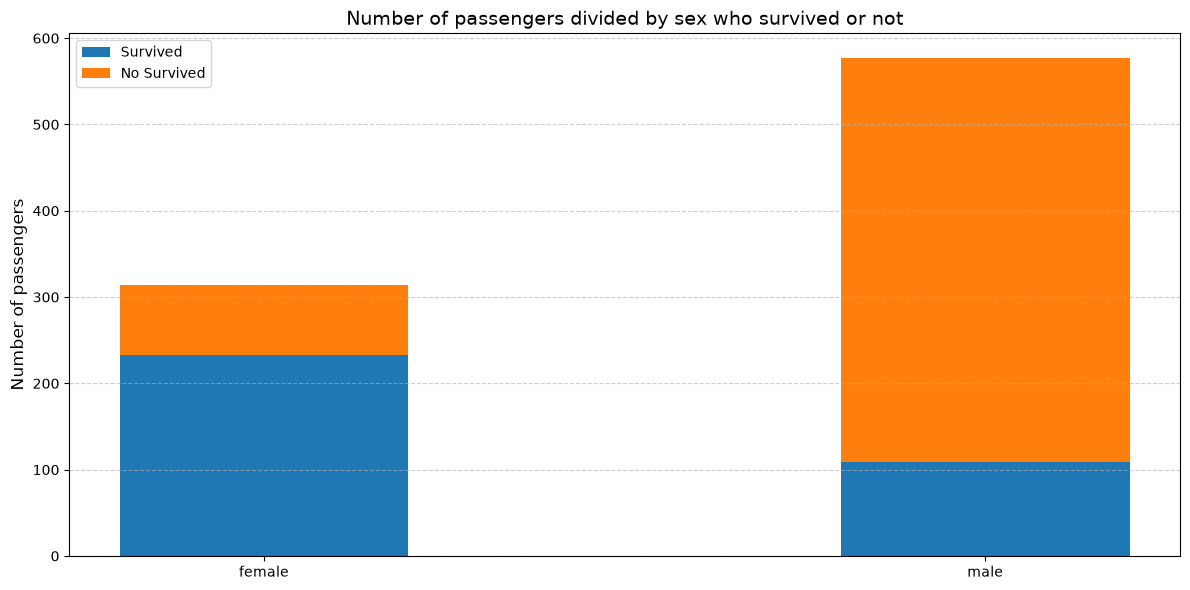

In [14]:
survived_sexs_count = titanic_df[titanic_df["Survived"] == 1]["Sex"].value_counts()

no_survived_sexs_count = titanic_df[titanic_df["Survived"] == 0]["Sex"].value_counts()

categories = ['female', 'male']
survived = survived_sexs_count.reindex(categories, fill_value=0)
no_survived = no_survived_sexs_count.reindex(categories, fill_value=0)


plt.figure(figsize=(12,6))

plt.bar(categories, survived.values, label="Survived", width=0.4)

plt.bar(categories, no_survived.values, bottom= survived_sexs_count.values, label="No Survived", width=0.4)

plt.title("Number of passengers divided by sex who survived or not", fontsize=14)
plt.ylabel("Number of passengers", fontsize=12)

plt.tight_layout()
plt.legend()
plt.grid(axis="y", alpha=0.6, linestyle="--")
plt.show()

In the plot above, we can see that have a big difference between `male` and `female` classes depends on whether it survived or not. With this plot, we can see that `Sex` variable is extremely important to determine if a passenger must be survived or not.

---

#### **1.2 Bar plots per passenger class**

[136  87 119]


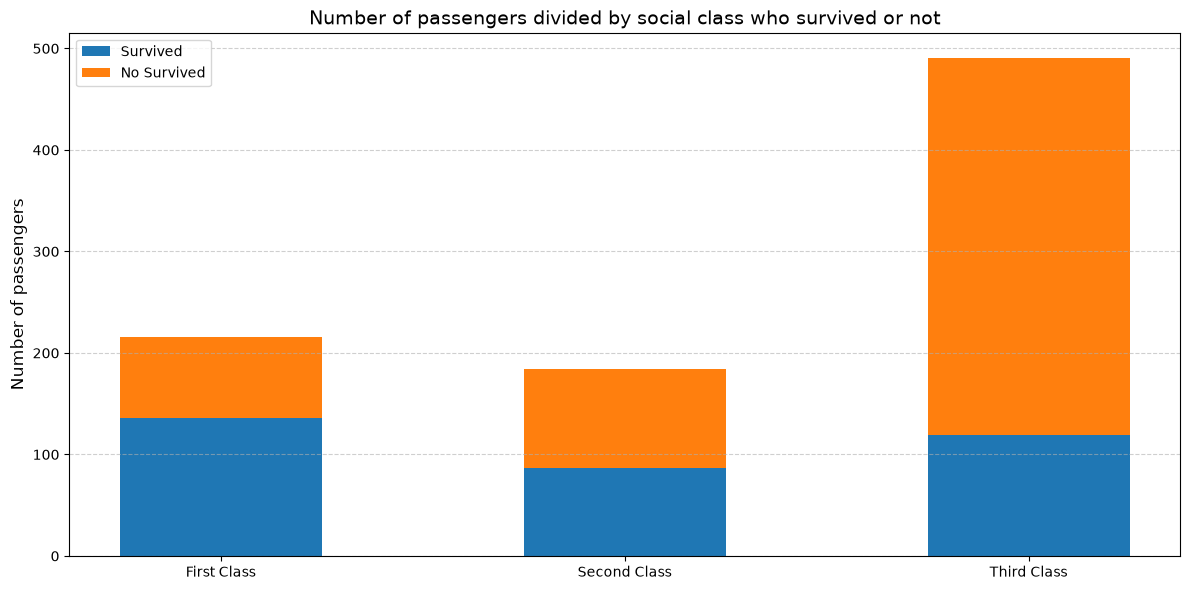

In [15]:
survived_pclass_count = titanic_df[titanic_df["Survived"] == 1]["Pclass"].value_counts()

no_survived_pclass_count = titanic_df[titanic_df["Survived"] == 0]["Pclass"].value_counts()

categories = [1, 2, 3] 
survived_pclass = survived_pclass_count.reindex(categories)
no_survived_pclass = no_survived_pclass_count.reindex(categories)

print(survived_pclass.values)

plt.figure(figsize=(12,6))

plt.bar(categories, survived_pclass.values, label="Survived", width=0.5)

plt.bar(categories, no_survived_pclass.values, bottom= survived_pclass.values, label="No Survived", width=0.5)

plt.title("Number of passengers divided by social class who survived or not", fontsize=14)
plt.ylabel("Number of passengers", fontsize=12)

plt.tight_layout()
plt.xticks(categories, ["First Class", "Second Class", "Third Class"])
plt.legend()
plt.grid(axis="y", alpha=0.6, linestyle="--")
plt.show()

In the plot above, we can see that we don't have a big difference between the different social classes on the Titanic, only in the first class have a small increase respect to the third class. So the `Pclass` variable could be contribute with some but not significantly as the previous variables.

---

#### **1.3 Correlation analysis respect to target variable**

We have other variables such as `Name`, `SibSp`, `Parch`, `Ticket`, `Ticket`, `Cabin`, `Embarked`, personally, I don't think they add value to the prediction; however, we can't establish a truth based on a hypothesis without first verifying its validity. To do this, we can create a heat map and examine the correlations between the variables, it's a useful and simple way to determine which features are related to the target variable. Howver the correlation matrix use only numerical variables, so for example `Name`, `Cabin`, `Embarked` are not considered, and also we can infer that the name of the passenger, cabin or the embarked doesn't contribute information that we have previously with the `Age`, `Pclass` and `Sex`. So I recommend to drop that three variables. For numerical variables we'll implement the heat map (or correlation matrix)

In [16]:
numeric_titanic_df = titanic_df[[
    "PassengerId",
    "Survived",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]]


corr_matrix = numeric_titanic_df.corr()

corr_matrix

,PassengerId,Survived,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.077221,-0.035322,0.081629,0.257307
Age,0.036847,-0.077221,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,0.096067,0.159651,0.216225,1.000000


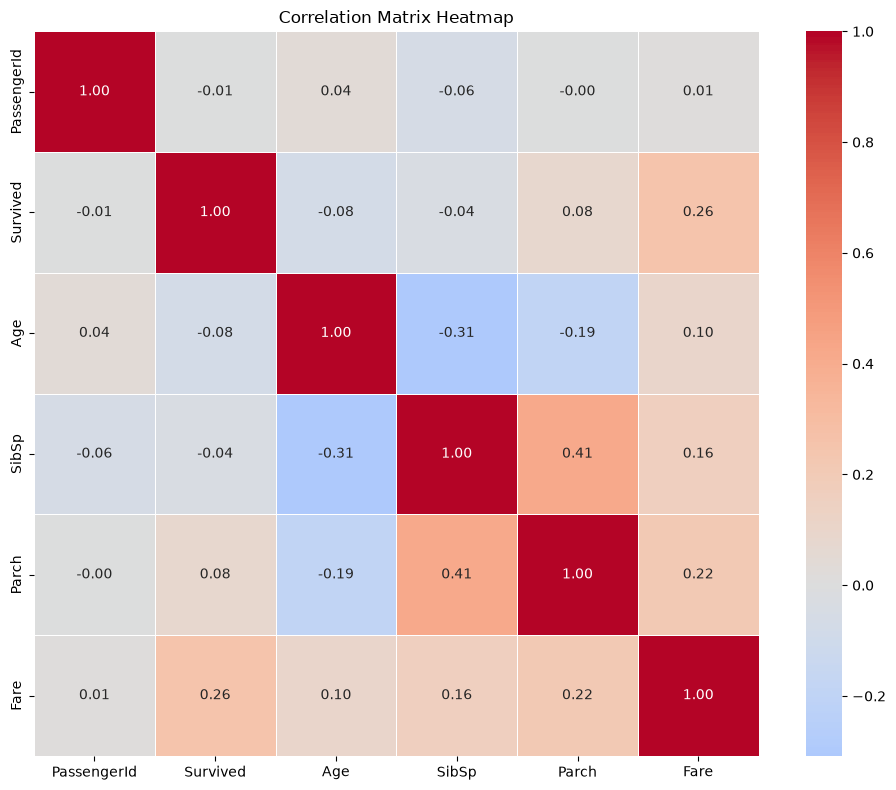

In [17]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

In the above heat map, we can see that out hypothesis that the Age of the passenger contributes to the prediction of the model was incorrect. Because of we can see that the most of the variables doesn't have a positive correlation on the contrary the variables are closer to 0 (no correlation). The only variable that has a higher correlation than the others is `Fare`; however, we have already captured that information in the `Pclass` variable, so this is a strong indication that the social class variable may be useful for the model.

Therefore, I recommend removing the numerical features to reduce the model’s training time.



> This is a simple analysis using only the correlation, we can use advanced plots and mathematical tools to determine the importance of any features to predict a target variable.

---

#### **1.4 Basic statistical Analysis of the dataset**

Finally, is recommended do a simple basic statistic analysis on the dataset to determine the quality of the data, because bad data leads to a bad model. Basic considerations to analyze the quality of the data are:
1. Percentage of duplicated records
2. Percentage of null records
3. Standard desviation (to identify bias)
4. Percentage of completeness
5. Percentage of uniqueness

For this work I'm going to do a basic analysis wit the `describe()` method and with *whisker plots* on the age column to analyze if we have outliers in our data.

In [18]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In the above command to view a basic statistical analysis we can see that the `Age` and `Fare` features have a lot of values with a lot of different values, for that reason we have a big *Standard Desviation*.

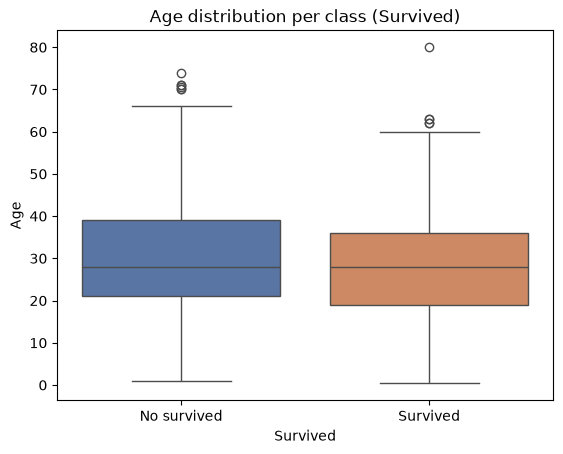

In [19]:
sns.boxplot(data=titanic_df, x='Survived', y='Age', 
            hue='Survived', palette=['#4C72B0', '#DD8452'], 
            legend=False)


plt.xticks([0, 1], ['No survived', 'Survived'])
plt.title('Age distribution per class (Survived)')
plt.show()

The distribution between two classes are lower, and have few outlier values on each class, so its manageable and the quality of the data is good with all of our previous analysis.


So, the final decision is preserve the following columns: `Survived`, `Pclass`, `Sex`, `Age (with doubts)`

and the columns which I'd drop are: `PassengerId`, `Name`, `SibSp`, `Parch`, `Ticket`, `Fare`, `Cabin`, `Embarked`

However, in the following sections, I need to apply data transformation techniques using the ``ColumnTransform`` class and create a ``Pipeline`` to automate the process; for this reason, the features I will exclude are:
PassengerId, Name, Ticket, and Cabin, since they have many unique values and, when applying the transformation through encoding, the dimensionality of the dataset increases.


---

In [20]:
titanic_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

## 2. Data division for training the Machine Learning model

To avoid the data leakage, we don't standarize data before the split, because if we use all data to apply the standarization with a scaler we can pass information about the training data to test data.

In [21]:
from tools.preprocessing import train_val_test_split, remove_labels


train_set, val_set, test_set = train_val_test_split(titanic_df, stratify='Survived')

In [22]:
print("Length of the Training Set:", len(train_set))
print("Length of the Validation Set:", len(val_set))
print("Length of Test Set:", len(test_set))
print("Lenght of the TOTAL dataset", titanic_df.shape[0])

Length of the Training Set: 534
Length of the Validation Set: 178
Length of Test Set: 179
Lenght of the TOTAL dataset 891


In [23]:
X_train, y_train = remove_labels(train_set, 'Survived')
X_val, y_val = remove_labels(val_set, 'Survived')
X_test, y_test = remove_labels(test_set, 'Survived')

## 3. Configurable preprocessing

The implementation of the methods for preprocessing and transform the data are in the ``tools`` path. I decided use modularity approach on this work, to have a cleaner notebook.

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from tools.transform import DataFramePreparer

For mananing *numerical data*, we can input with three options: ``['mean', 'mode', 'median']``, and Standarize with two: `['ROBUST', 'ROBUSTSCALER', 'STANDARD', 'STANDARDSCALER']`.

In the case of *categorical data*, the used strategy for input data are the `most_frequen_value (mode)`, and the encoding techiques are: `['ONE-HOT', 'LABEL']` (one-hot-enconding or label-encoding)

In the following section you can see a brief visualization on tabular format with a different combinations of the implemented strategies.

#### 3.1 Using `mean` - `Standard Scaler` and `One-Hot Enconding`

In [25]:
X_train_raw = X_train.copy()

null_rows = X_train_raw[X_train_raw.isna().any(axis=1)].index
X_train_raw.loc[null_rows].head(10)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
768,3,male,NaN,1,0,24.1500,Q
121,3,male,NaN,0,0,8.0500,S
783,3,male,NaN,1,2,23.4500,S
77,3,male,NaN,0,0,8.0500,S
517,3,male,NaN,0,0,24.1500,Q
527,1,male,NaN,0,0,221.7792,S
490,3,male,NaN,1,0,19.9667,S
832,3,male,NaN,0,0,7.2292,C
573,3,female,NaN,0,0,7.7500,Q
674,2,male,NaN,0,0,0.0000,S


In [26]:
prep_mean_one_hot = DataFramePreparer("mean", "ONE-HOT")
prep_mean_one_hot_df = prep_mean_one_hot.fit(X_train_raw).transform(X_train_raw)

prep_mean_one_hot_df.loc[null_rows].head(10)

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
768,0.0,0.0,1.0,0.0,0.448915,0.0,1.0,0.0,1.0,0.0
121,0.0,0.0,0.0,0.0,-0.279454,0.0,1.0,0.0,0.0,1.0
783,0.0,0.0,1.0,2.0,0.417246,0.0,1.0,0.0,0.0,1.0
77,0.0,0.0,0.0,0.0,-0.279454,0.0,1.0,0.0,0.0,1.0
517,0.0,0.0,0.0,0.0,0.448915,0.0,1.0,0.0,1.0,0.0
527,-2.0,0.0,0.0,0.0,9.389713,0.0,1.0,0.0,0.0,1.0
490,0.0,0.0,1.0,0.0,0.259661,0.0,1.0,0.0,0.0,1.0
832,0.0,0.0,0.0,0.0,-0.316587,0.0,1.0,1.0,0.0,0.0
573,0.0,0.0,0.0,0.0,-0.293026,1.0,0.0,0.0,1.0,0.0
674,-1.0,0.0,0.0,0.0,-0.643638,0.0,1.0,0.0,0.0,1.0


All missing values (`NaN`) in numerical features (like `Age`) are transformed to `0.000000`. This is the expected result:

* **Imputation:** Missing values are replaced by the mean (or median).
* **Scaling:** `StandardScaler` (or `RobustScaler`) centers the distribution around zero by subtracting the mean:
  $$\text{Age}_{\text{scaled}} = \frac{\text{Age} - \mu}{\sigma} = \frac{\mu - \mu}{\sigma} = \mathbf{0.0}$$

Therefore, `0.0` represents passengers imputed with the average age, positive values represent older passengers, and negative values represent younger passengers.

---

#### 3.2 Using `mode` - `Standard Scaler` and `Label Enconding`

In [27]:
prep_mode_label_encode = DataFramePreparer("mode", "LABEL")
prep_mode_label_encode_df = prep_mode_label_encode.fit(X_train_raw).transform(X_train_raw)

prep_mode_label_encode_df.loc[null_rows].head(10)

,Pclass,Age,SibSp,Parch,Fare,Sex,Embarked
768,0.0,-0.214286,1.0,0.0,0.448915,1.0,1.0
121,0.0,-0.214286,0.0,0.0,-0.279454,1.0,2.0
783,0.0,-0.214286,1.0,2.0,0.417246,1.0,2.0
77,0.0,-0.214286,0.0,0.0,-0.279454,1.0,2.0
517,0.0,-0.214286,0.0,0.0,0.448915,1.0,1.0
527,-2.0,-0.214286,0.0,0.0,9.389713,1.0,2.0
490,0.0,-0.214286,1.0,0.0,0.259661,1.0,2.0
832,0.0,-0.214286,0.0,0.0,-0.316587,1.0,0.0
573,0.0,-0.214286,0.0,0.0,-0.293026,0.0,1.0
674,-1.0,-0.214286,0.0,0.0,-0.643638,1.0,2.0


#### 3.2 Using `median` - `Robust Scaler` and `Label Enconding`

In [28]:
prep_median_label_encode = DataFramePreparer("median", "LABEL")
prep_median_label_encode_df = prep_mode_label_encode.fit(X_train_raw).transform(X_train_raw)

prep_median_label_encode_df.loc[null_rows].head(10)

,Pclass,Age,SibSp,Parch,Fare,Sex,Embarked
768,0.0,-0.214286,1.0,0.0,0.448915,1.0,1.0
121,0.0,-0.214286,0.0,0.0,-0.279454,1.0,2.0
783,0.0,-0.214286,1.0,2.0,0.417246,1.0,2.0
77,0.0,-0.214286,0.0,0.0,-0.279454,1.0,2.0
517,0.0,-0.214286,0.0,0.0,0.448915,1.0,1.0
527,-2.0,-0.214286,0.0,0.0,9.389713,1.0,2.0
490,0.0,-0.214286,1.0,0.0,0.259661,1.0,2.0
832,0.0,-0.214286,0.0,0.0,-0.316587,1.0,0.0
573,0.0,-0.214286,0.0,0.0,-0.293026,0.0,1.0
674,-1.0,-0.214286,0.0,0.0,-0.643638,1.0,2.0


## 4. Complete Pipeline

This feature was implemented on the `transform.py` with the `build_full_pipeline` method to unify the numeric and categorical pipelines.

## 5. Experimentation


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tools.transform import build_full_pipeline

def run_pipeline_experiments(experiments, X_train, y_train, X_val, y_val, random_state=15):
    
    results = []
    for exp in experiments:
        # 1. Construct the complete pipeline
        pipeline = build_full_pipeline(
            numeric_strategy=exp["numeric_strategy"],
            category_strategy=exp["category_strategy"],
            scaler_strategy=exp["scaler_strategy"],
            random_state=random_state,
            max_iter=1000
        )
        # Train the pipeline
        pipeline.fit(X_train, y_train)

        # Use the predict method on the last element in the pipeline
        y_pred = pipeline.predict(X_val)

        # Compute metrics
        results.append({
            "Experiment": exp["name"],
            "Imputer": exp["numeric_strategy"].capitalize(),
            "Encoding": exp["category_strategy"],
            "Scaler": exp["scaler_strategy"].capitalize(),
            "Accuracy": accuracy_score(y_val, y_pred),
            "Precision": precision_score(y_val, y_pred, zero_division=0),
            "Recall": recall_score(y_val, y_pred, zero_division=0),
            "F1-Score": f1_score(y_val, y_pred, zero_division=0)
        })

    df_results = pd.DataFrame(results)
    return df_results

In [30]:
experiments_config = [
    {
        "name": "Config 1 (Mean + One-Hot + Robust)",
        "numeric_strategy": "mean",
        "category_strategy": "ONE-HOT",
        "scaler_strategy": "ROBUST"
    },
    {
        "name": "Config 2 (Mean + One-Hot + Standard)",
        "numeric_strategy": "mean",
        "category_strategy": "ONE-HOT",
        "scaler_strategy": "STANDARD"
    },
    {
        "name": "Config 3 (Median + One-Hot + Robust)",
        "numeric_strategy": "median",
        "category_strategy": "ONE-HOT",
        "scaler_strategy": "ROBUST"
    },
    {
        "name": "Config 4 (Median + One-Hot + Standard)",
        "numeric_strategy": "median",
        "category_strategy": "ONE-HOT",
        "scaler_strategy": "STANDARD"
    },
    {
        "name": "Config 5 (Mode + Ordinal/Label + Robust)",
        "numeric_strategy": "mode",
        "category_strategy": "LABEL",
        "scaler_strategy": "ROBUST"
    },
    {
        "name": "Config 6 (Median + Ordinal/Label + Standard)",
        "numeric_strategy": "median",
        "category_strategy": "LABEL",
        "scaler_strategy": "STANDARD"
    }
]

In [34]:
results_table = run_pipeline_experiments(experiments_config, X_train, y_train, X_val, y_val)

display(results_table.round(4))

,Experiment,Imputer,Encoding,Scaler,Accuracy,Precision,Recall,F1-Score
0,Config 1 (Mean + One-Hot + Robust),Mean,ONE-HOT,Robust,0.8090,0.7742,0.7059,0.7385
1,Config 2 (Mean + One-Hot + Standard),Mean,ONE-HOT,Standard,0.8146,0.7778,0.7206,0.7481
2,Config 3 (Median + One-Hot + Robust),Median,ONE-HOT,Robust,0.8034,0.7619,0.7059,0.7328
3,Config 4 (Median + One-Hot + Standard),Median,ONE-HOT,Standard,0.8034,0.7619,0.7059,0.7328
4,Config 5 (Mode + Ordinal/Label + Robust),Mode,LABEL,Robust,0.8146,0.7692,0.7353,0.7519
5,Config 6 (Median + Ordinal/Label + Standard),Median,LABEL,Standard,0.8090,0.7656,0.7206,0.7424


## 6. Analysis

- **Which configuration yielded the best results?**

    The configuration number 5 (Mode + Ordinal/Label + Robust)

- **Did the preprocessing method affect the model's performance?**

    It did, but not significantly; for most configurations, the differences are small.

- **When would you use StandardScaler, MinMaxScaler, and RobustScaler?**
  
    **StandardScaler** is ideal when numerical features follow an approximately normal (Gaussian) distribution without extreme outliers.; **MinMaxScaler** should be used when features must be strictly bounded within a fixed range such as $[0, 1]$, provided there are no outliers; and **RobustScaler** is the best choice when the dataset contains significant outliers or skewed distributions, as it uses the median and interquartile range (IQR) to scale data without being distorted by extreme values.

- **What is the difference between one-hot encoding and assigning integer values to categories?**

    One-hot encoding eliminates the problem of the ML model prioritizing higher values in the categories. In other words, if we have (Coca-Cola, Pepsi, Fanta) and assign integers as categories (0, 1, 2), The model will believe that Fanta is better than the other two. But with one-hot encoding, this does not happen—at the cost of increasing the dimensionality of our records.


- **What is data leakage, and how can it be prevented using pipelines?**

    Data leakage is the transfer of information from the training set directly to the validation or testing set, causing the model to learn from the data it will be trained on. Using pipelines helps us solve this problem only if we split the dataset beforehand and, once split, apply imputation techniques using statistical values based SOLELY on the values from the training set.

- **Pclass appears as a numerical variable. Would you treat it as numerical or categorical? Explain your reasoning.**

    I would treat it as a numerical variable, since when discussing social classes in the context of the Titanic, we know by default that a hierarchy exists, where first class is higher than third class. Therefore, it can contribute a certain value to th

- **Is there a single preprocessing strategy that is always the best?**

    No, preprocessing combinations depend on the overall nature of our data—for example, removing outliers, since this can affect the mean imputation technique as well as other techniques. It is also important to consider the seed factor, which is why there is no single strategy that is always the best.

## Final Requirement

In [38]:
import numpy as np

# Config 5 (Mode + Ordinal/Label + Robust)	

best_pipeline = build_full_pipeline(
    numeric_strategy="mode",
    category_strategy="LABEL",
    scaler_strategy="ROBUST",
    random_state=15
)
best_pipeline.fit(X_train, y_train)


# New passengers without preprocessing
new_passengers_data = {
    "Pclass": [2, 1, 2],
    "Sex": ["female", "male", "male"],
    "Age": [22.0, np.nan, 48.0],        
    "SibSp": [0, 1, 0],
    "Parch": [0, 0, 1],
    "Fare": [150.0, 7.85, 140.0], 
    "Embarked": ["S", "Q", "C"]
}


df_new_passengers = pd.DataFrame(new_passengers_data)


predictions = best_pipeline.predict(df_new_passengers)
probabilities = best_pipeline.predict_proba(df_new_passengers)

df_results_new = df_new_passengers.copy()
df_results_new["Predicted_Class"] = ["Survived (1)" if p == 1 else "Not Survived (0)" for p in predictions]
df_results_new["Survival_Probability (%)"] = (probabilities[:, 1] * 100).round(2)

print("\nPredcition Results")
display(df_results_new)


Predcition Results


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Predicted_Class,Survival_Probability (%)
0,2,female,22.0,0,0,150.00,S,Survived (1),86.47
1,1,male,NaN,1,0,7.85,Q,Not Survived (0),49.41
2,2,male,48.0,0,1,140.00,C,Not Survived (0),21.18
